# Домашнее задание 8. Мониторинг

Прослеживаемость конвейера (и кода, и данных) должна закладываться **до проектирования** (в идеале, на основе синтезированного трафика от системы нагрузочного тестирования Locust/k6s/ab/...).


## 1. Определить ключевые бизнес- и технические метрики для ML-системы

Чтобы разработка могла сдвинуться с мертвой точки, создайте сбаланисированное дерево метрик, которое бы учитывало точки зрения разных команд.


|Требования бизнеса|Требования разработчиков|Требования команды ML|Требования DevOps|
|------------------|------------------------|---------------------|-----------|
|Нужно увеличить выручку онлайн-кинотеатра|Нужен новый сервер |Нужен GPU      | Вы существующие мощности недогружаете |
|...пиковая нагрузка 10000 RPS|Нужно переходить на ClickHouse? |Сколько фильмов выводить для рекомендательной системы?      |Есть Postgres, он выдает 1000 RPS, потому что мы обернули Docker-in-Docker         |
|...и чтобы быстрый был|Нужно переписать бэкенд?|Нужно переходить на стримы? | Какое нужно время отклика? |
|...и чтобы надежный был| Сделать на Kubernetes? |Сделать на KubeFlow? | SLA 100% нет даже на бирже  |

Желательно использовать [adr-tools](https://github.com/npryce/adr-tools), чтобы записывать **причины**, по которым мы начали принимать решения и **риски**, из-за которых ML-система может работать не так, как ожидается.


*Ожидаемый артефакт: создающий диаграмму код в [ячейке](#scrollTo=y2v5KaAkw0zx)*

In [1]:
!pip install diagrams -q

from diagrams import Diagram, Cluster, Edge
from diagrams.programming.language import Python
from diagrams.onprem.monitoring import Prometheus, Grafana
from diagrams.aws.management import Cloudwatch
from IPython.display import Image
from diagrams import Diagram, Cluster, Edge
from diagrams.onprem.queue import Kafka
from diagrams.onprem.workflow import Airflow
from diagrams.aws.compute import EC2, Lambda
from diagrams.aws.storage import S3
from diagrams.aws.ml import Sagemaker
from diagrams.programming.language import Python
from IPython.display import Image

# Создаём диаграмму дерева метрик
with Diagram("ML System Metrics Tree",
             filename="/content/metrics_tree_diagram",
             show=False,
             direction="TB",
             outformat="png"):

    # УРОВЕНЬ 1: БИЗНЕС-МЕТРИКИ
    with Cluster("БИЗНЕС-МЕТРИКИ (Business KPIs)"):
        revenue = Python("Выручка от рекламы (RPS)")
        conversion = Python("Конверсия (просмотр → клик)")
        roi = Python("ROI рекламных кампаний")

    # УРОВЕНЬ 2: SLO ПРИЛОЖЕНИЯ
    with Cluster("SLO / МЕТРИКИ ПРИЛОЖЕНИЯ (App Metrics)"):
        availability = Python("Доступность (SLA) > 99.9%")
        latency = Python("Latency (p95, p99) < 1 сек")
        error_rate = Python("Error Rate < 1%")
        throughput = Python("Throughput (RPS)")

    # УРОВЕНЬ 3: ML-МЕТРИКИ
    with Cluster("МЕТРИКИ МОДЕЛИ (ML Model Metrics)"):
        accuracy = Python("Accuracy / F1 > 0.95")
        data_drift = Python("Дрифт данных (PSI) < 0.1")
        concept_drift = Python("Дрифт концепции")
        inference_time = Python("Время инференса (мс)")

    # УРОВЕНЬ 4: ИНФРАСТРУКТУРА
    with Cluster("МЕТРИКИ ИНФРАСТРУКТУРЫ (Infrastructure)"):
        cpu = Python("CPU Использование")
        ram = Python("RAM Использование")
        disk = Python("Диск IOPS")
        network = Python("Сеть Traffic")

    # СИСТЕМА МОНИТОРИНГА
    with Cluster("СИСТЕМА МОНИТОРИНГА (Monitoring)"):
        prometheus = Prometheus("Prometheus\nСбор метрик")
        grafana = Grafana("Grafana\nВизуализация")
        alerts = Cloudwatch("Алерты\n(Telegram/Slack)")

    # СВЯЗИ
    # Бизнес → SLO
    revenue >> availability
    conversion >> availability
    roi >> availability

    # SLO → ML
    availability >> accuracy
    latency >> inference_time
    error_rate >> data_drift

    # ML → Инфраструктура
    accuracy >> cpu
    data_drift >> ram
    inference_time >> disk

    # Мониторинг собирает метрики
    availability >> prometheus
    latency >> prometheus
    error_rate >> prometheus
    accuracy >> prometheus
    data_drift >> prometheus
    cpu >> prometheus
    ram >> prometheus

    prometheus >> grafana
    grafana >> alerts


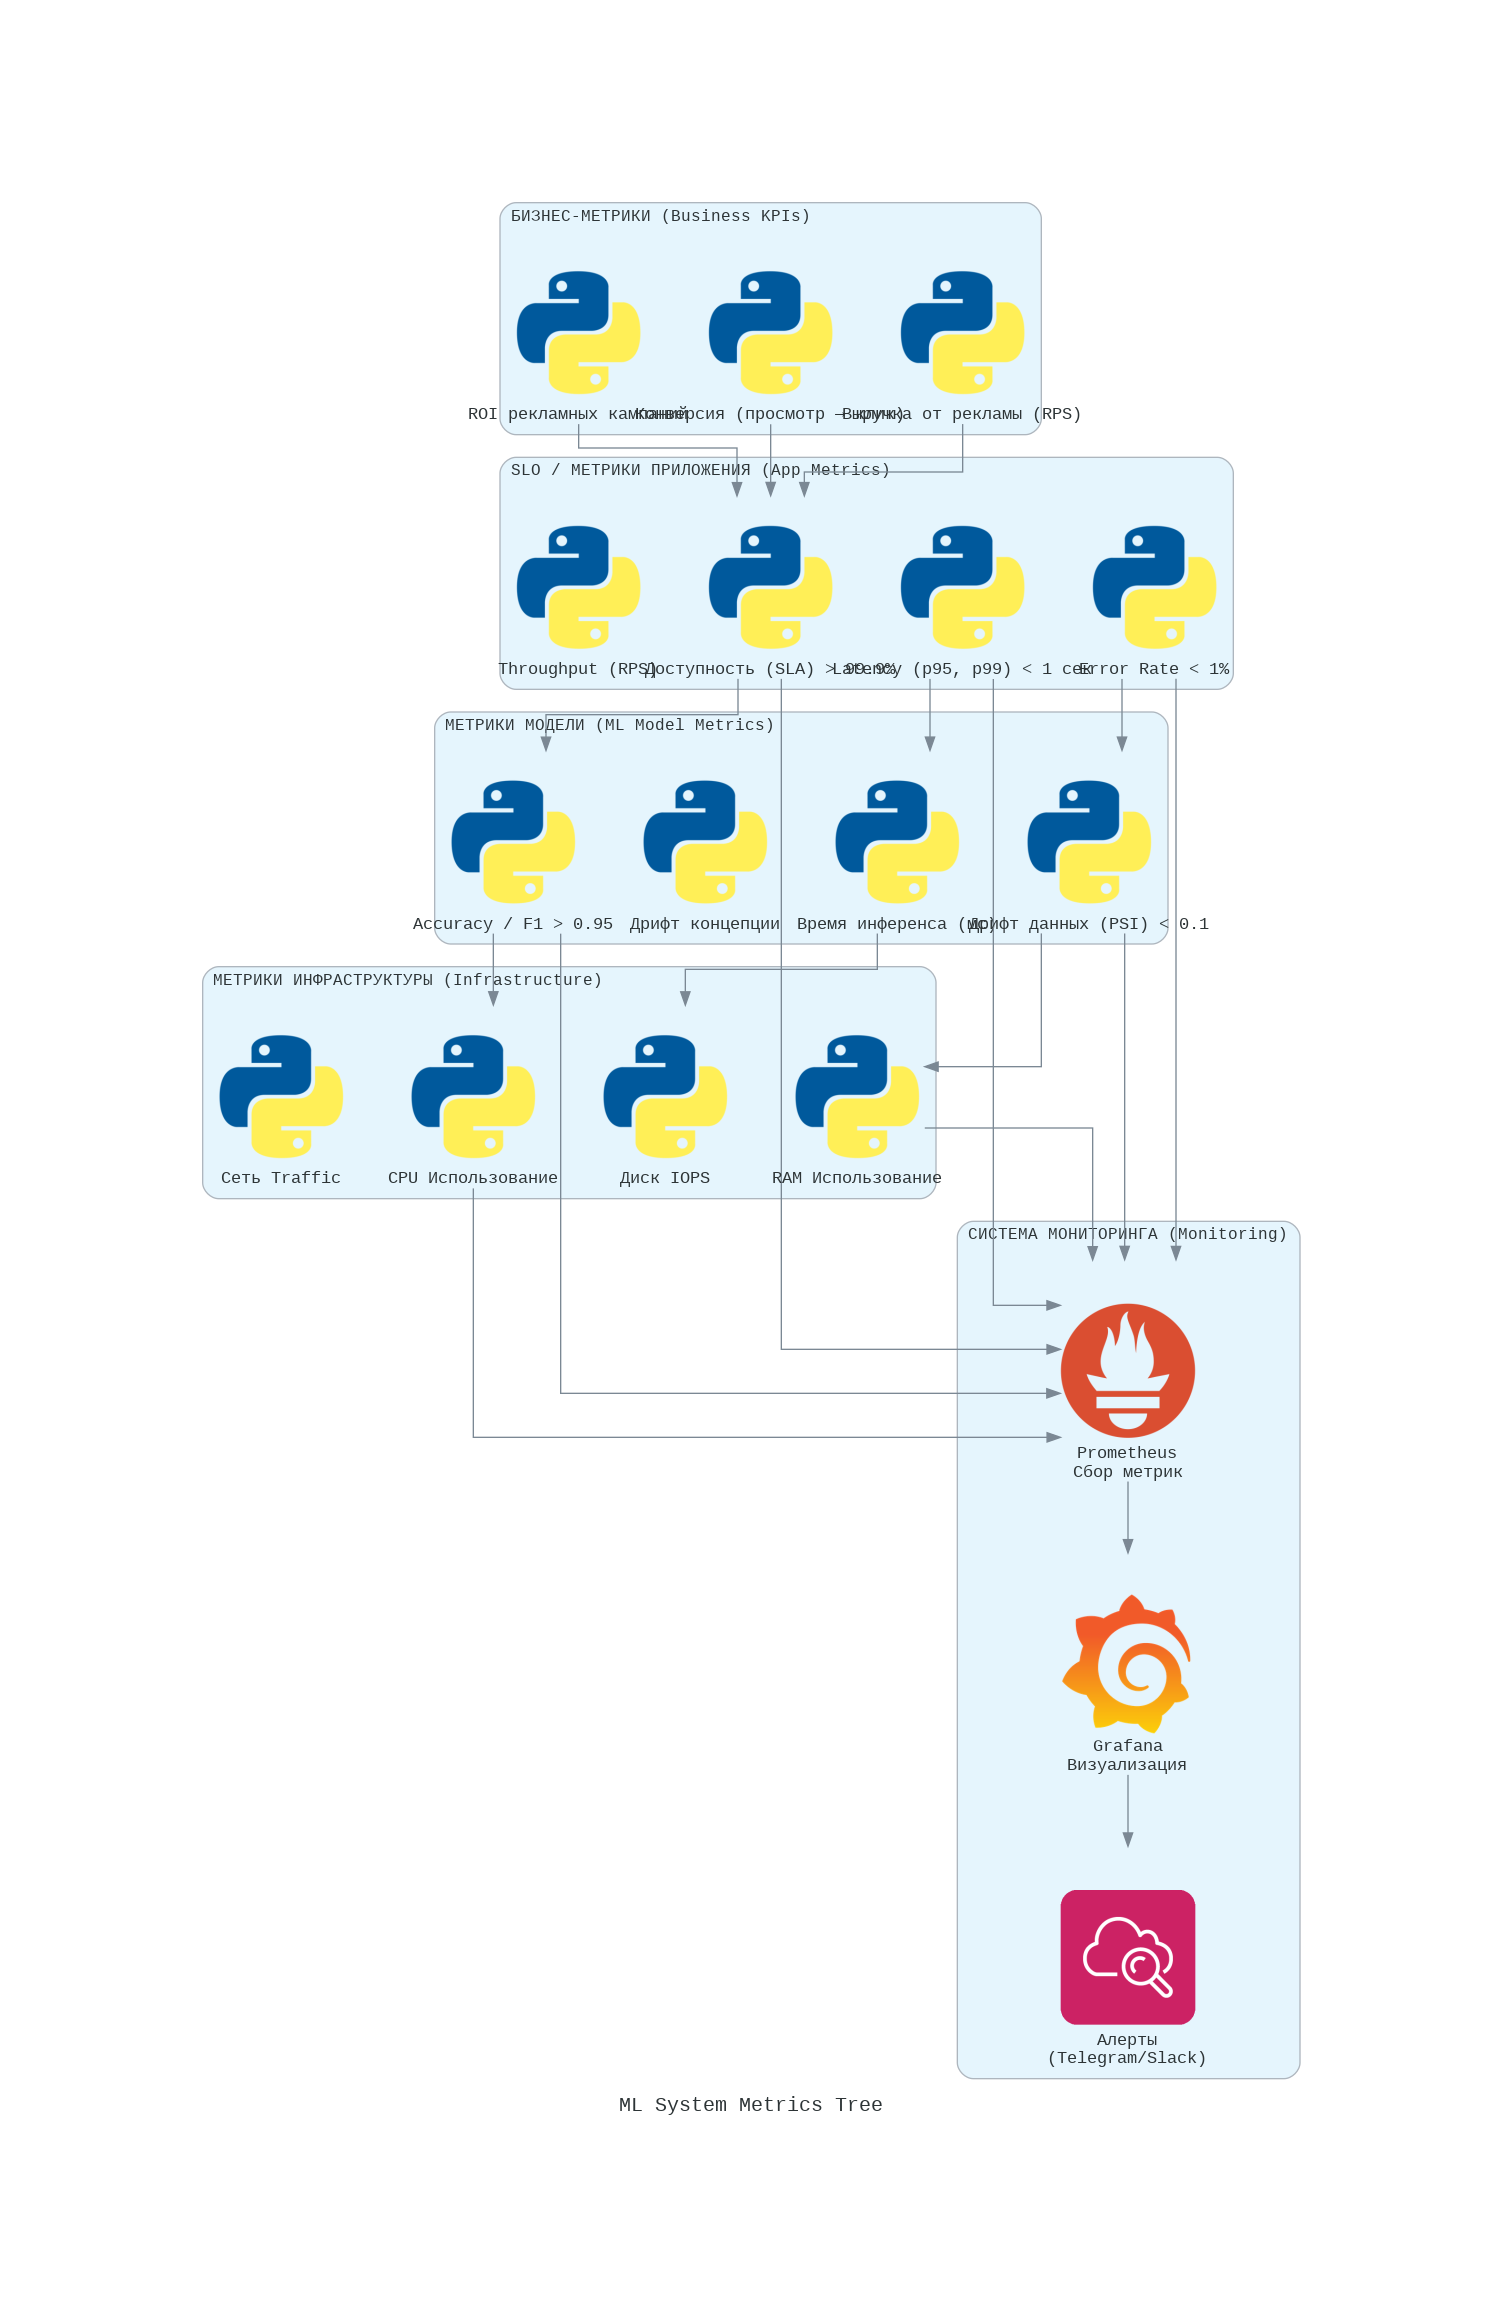

In [2]:
from IPython.display import Image
Image("/content/metrics_tree_diagram.png")

## 2. Настроить мониторинг с использованием Prometheus, Grafana, MLflow


Желательно (но не обязательно) ознакомиться с инициативой по стандартизации [метрик](https://github.com/OpenSLO/OpenSLO), можно попробовать редактировать в [онлайн-редакторе](https://live.sloth.dev/?slo-spec=G4UwTgzglg9gdgLgAQCIAOYYFsQBcAWIArhAPTACMKAUBOMFAMYjIpYCedYDzNANgEMARiD4QE1JEhgB3OOFYdcIAVhpSwINDEXsYYAOakOXHiHVJcUBagBMNCHxjjJSAMRIA6iCQC+TmSQAMwEoPig4AyQACgBWAA943zgAEyQAFlsATgBKJAokTQBHIhAIXCQQUDB2fIAGBsKQErLcCBisrIA6LIBSHK7XAFokOFUWVGLS8oghgWBQwSEwqFx2CykYIQArEEYrUGROntcpFLLGMCg0K3hWAGFsLHgkAGUAGQB5JCEBOjSXvNFsIVmtgvokAAJAAq0IACk0WuUmhBtHA6BAuhskI4oBIpATKqA4G18YSCeBMGAAPotGrICBELDRMACZTRfC4XBoalTVrUlJEVm3ODUuiMeApCDUiVEEkAb22WwAvGxOPQmOYADQS87KgB+KDiXS6AB9MrkUABfADa8vlXRkERSsitVoAujkcqdybgYLg-LTSvScUyWWyQByuTy+eUBUK2bBReLJdLZQqlUJVSYNbxbfbHc7XR6vT6-OArJEyYSxjhkABZdivXMgSFQAz4ACiYCpACUIz6pEtRC5yQTGBGDPp2KwgWEQeE1tipAI4HB-Yn4KOx+4kJ9qjIrsokOcQkQ+BVXk4CG8vr4+BXQ1hnwIatI4JYmABrPDJNJoAQDB8cswDaQYdyfLBXxnVA2w7SoewhYUfBeAByHNuE1VDEWmNoUTRDFlyQACgOpEDcGrclhzESixzoapVhgki8BULBB3JTAiErAxqR-GClFY9irEYH9cDIh9QNoglqO3CD6PARjWEcAQRKIwllJEmV8FXeQ+FYNxyNmATVBQIA)


Принимая во внимание дерево метрик, выбранных в предыдущей [ячейке](#scrollTo=64bcf49d), нужно выбрать **одну** метрику и поставить ее на мониторинг.


*Ожидаемый артефакт: yaml в [ячейке](#scrollTo=Q0xhdA3Sw1XY) дашборд в [ячейке](#scrollTo=s7cw3qhud3Dx)*


In [3]:
%%writefile prometheus.yml
global:
  scrape_interval: 15s
  evaluation_interval: 15s

scrape_configs:
  - job_name: 'prometheus'
    static_configs:
      - targets: ['localhost:9090']

  - job_name: 'ml-service'
    static_configs:
      - targets: ['ml-service:8000']
    metrics_path: '/metrics'

alerting:
  alertmanagers:
    - static_configs:
        - targets: []

rule_files:
  - 'alerts.yml'

Overwriting prometheus.yml


In [4]:
%%writefile alerts.yml
groups:
  - name: ml_service_alerts
    interval: 30s
    rules:
      - alert: HighLatency
        expr: histogram_quantile(0.95, sum(rate(request_latency_seconds_bucket[5m])) by (le)) > 1
        for: 2m
        labels:
          severity: warning
        annotations:
          summary: "High latency detected"
          description: "p95 latency exceeded 1s"

      - alert: ServiceDown
        expr: up{job="ml-service"} == 0
        for: 1m
        labels:
          severity: critical
        annotations:
          summary: "ML Service is down"

Overwriting alerts.yml


In [5]:
%%writefile docker-compose.yml
version: '3.8'

services:
  prometheus:
    image: prom/prometheus:latest
    container_name: prometheus
    volumes:
      - ./prometheus.yml:/etc/prometheus/prometheus.yml
      - ./alerts.yml:/etc/prometheus/alerts.yml
    ports:
      - "9090:9090"
    networks:
      - monitoring

  grafana:
    image: grafana/grafana:latest
    container_name: grafana
    ports:
      - "3000:3000"
    environment:
      - GF_SECURITY_ADMIN_USER=admin
      - GF_SECURITY_ADMIN_PASSWORD=admin
    volumes:
      - grafana-storage:/var/lib/grafana
    depends_on:
      - prometheus
    networks:
      - monitoring

volumes:
  grafana-storage:

networks:
  monitoring:
    driver: bridge

Overwriting docker-compose.yml


In [6]:
%%writefile app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import numpy as np
import time
import logging
from prometheus_client import Histogram, Counter, generate_latest, CONTENT_TYPE_LATEST
from prometheus_client import REGISTRY
from fastapi.responses import Response

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

app = FastAPI(title="ML Service")

# Метрики Prometheus
REQUEST_LATENCY = Histogram('request_latency_seconds', 'Request latency', buckets=[0.01, 0.05, 0.1, 0.5, 1, 2, 5])
REQUEST_COUNT = Counter('http_requests_total', 'Total requests', ['method', 'endpoint', 'status'])

class PredictRequest(BaseModel):
    features: list[float]

@app.get("/metrics")
async def get_metrics():
    return Response(content=generate_latest(REGISTRY), media_type=CONTENT_TYPE_LATEST)

@app.get("/health")
async def health_check():
    REQUEST_COUNT.labels(method="GET", endpoint="/health", status="200").inc()
    return {"status": "ok", "version": "v1.0.0"}

@app.post("/predict")
async def predict(request: PredictRequest):
    start_time = time.time()
    REQUEST_COUNT.labels(method="POST", endpoint="/predict", status="200").inc()

    # Имитация инференса
    time.sleep(0.05)  # 50ms latency

    latency = time.time() - start_time
    REQUEST_LATENCY.observe(latency)

    return {"prediction": 0, "latency_ms": latency * 1000}

Overwriting app.py


In [7]:
%%writefile requirements.txt
fastapi
uvicorn
prometheus-client
numpy
scikit-learn

Overwriting requirements.txt


In [8]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Overwriting Dockerfile


In [9]:
%%writefile dashboard.json
{
  "title": "ML Service Monitoring",
  "uid": "ml-service-dashboard",
  "panels": [
    {
      "title": "p95 Latency",
      "type": "graph",
      "targets": [
        {
          "expr": "histogram_quantile(0.95, sum(rate(request_latency_seconds_bucket[5m])) by (le))",
          "legendFormat": "p95 latency"
        }
      ],
      "gridPos": {"h": 8, "w": 12, "x": 0, "y": 0}
    },
    {
      "title": "Requests Rate",
      "type": "graph",
      "targets": [
        {
          "expr": "rate(http_requests_total[5m])",
          "legendFormat": "{{method}} {{endpoint}}"
        }
      ],
      "gridPos": {"h": 8, "w": 12, "x": 12, "y": 0}
    },
    {
      "title": "Error Rate",
      "type": "stat",
      "targets": [
        {
          "expr": "sum(rate(http_requests_total{status=~\"5..\"}[5m])) / sum(rate(http_requests_total[5m]))",
          "legendFormat": "error rate"
        }
      ],
      "gridPos": {"h": 4, "w": 6, "x": 0, "y": 8}
    },
    {
      "title": "Active Requests",
      "type": "stat",
      "targets": [
        {
          "expr": "active_requests",
          "legendFormat": "active"
        }
      ],
      "gridPos": {"h": 4, "w": 6, "x": 6, "y": 8}
    },
    {
      "title": "Service Uptime",
      "type": "stat",
      "targets": [
        {
          "expr": "up{job=\"ml-service\"}",
          "legendFormat": "status"
        }
      ],
      "gridPos": {"h": 4, "w": 6, "x": 12, "y": 8}
    },
    {
      "title": "CPU Usage (Container)",
      "type": "graph",
      "targets": [
        {
          "expr": "rate(container_cpu_usage_seconds_total{container=\"ml-service\"}[5m])",
          "legendFormat": "CPU"
        }
      ],
      "gridPos": {"h": 8, "w": 12, "x": 0, "y": 12}
    },
    {
      "title": "Memory Usage (Container)",
      "type": "graph",
      "targets": [
        {
          "expr": "container_memory_usage_bytes{container=\"ml-service\"} / 1024 / 1024",
          "legendFormat": "RAM (MB)"
        }
      ],
      "gridPos": {"h": 8, "w": 12, "x": 12, "y": 12}
    }
  ]
}

Overwriting dashboard.json


In [10]:
%%writefile alerts.yml
groups:
  - name: ml_service_alerts
    interval: 30s
    rules:
      - alert: HighLatency
        expr: histogram_quantile(0.95, sum(rate(request_latency_seconds_bucket[5m])) by (le)) > 1
        for: 2m
        labels:
          severity: warning
          component: ml-service
        annotations:
          summary: "High request latency detected"
          description: "p95 latency exceeded 1s"

      - alert: HighErrorRate
        expr: sum(rate(http_requests_total{status=~"5.."}[5m])) / sum(rate(http_requests_total[5m])) > 0.01
        for: 2m
        labels:
          severity: critical
          component: ml-service
        annotations:
          summary: "High error rate detected"
          description: "Error rate exceeded 1%"

      - alert: ServiceDown
        expr: up{job="ml-service"} == 0
        for: 1m
        labels:
          severity: critical
          component: ml-service
        annotations:
          summary: "ML Service is down"
          description: "Service has been down for more than 1 minute"

Overwriting alerts.yml


## 3. Обнаружить деградацию модели и дрифт

Вспомните материалы [семинара](https://colab.research.google.com/drive/1OVBFG3bRLmmmVj31Ob5LFhKQTAi7f-Hn?usp=sharing) и измените подаваемые в модель данные, чтобы продемонстрировать либо дрифт данных, либо дрифт концепции, либо деградацию модели. Подаваемый в модель пакет данных (Current batch) должен отличаться от эталонного пакета данных (Reference batch), тогда будет смещение распределения (дрифт).


*Ожидаемый артефакт: код в [ячейке](#scrollTo=lq14Cx_GxYSM)*


In [11]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import ks_2samp

print("ОБНАРУЖЕНИЕ ДРИФТА ДАННЫХ И ДЕГРАДАЦИИ МОДЕЛИ")

# Загружаем данные
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Эталонные данные (без дрифта) — первые 100 строк
reference_data = df.iloc[:100].copy()

# Текущие данные С ДРИФТОМ — последние 50 строк, признаки умножены на 2
current_data = df.iloc[100:].copy()
current_data[iris.feature_names] = current_data[iris.feature_names] * 2

print(f"\nЭталонных данных: {len(reference_data)} строк")
print(f"Текущих данных (с дрифтом): {len(current_data)} строк")

# Функция для расчёта PSI (Population Stability Index)
def calculate_psi(expected, actual, bins=10):
    expected_percents, bins_edges = np.histogram(expected, bins=bins, density=False)
    actual_percents, _ = np.histogram(actual, bins=bins_edges, density=False)

    # Добавляем маленькое значение, чтобы избежать деления на ноль
    expected_percents = expected_percents + 1e-10
    actual_percents = actual_percents + 1e-10

    expected_percents = expected_percents / np.sum(expected_percents)
    actual_percents = actual_percents / np.sum(actual_percents)

    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi

# Анализ дрифта по каждому признаку
print("\nАНАЛИЗ ДРИФТА ДАННЫХ (PSI):")
print(f"{'\nПризнак':<25} {'PSI':<10} {'Статус':<15}")

for feature in iris.feature_names:
    ref_values = reference_data[feature].values
    curr_values = current_data[feature].values

    psi = calculate_psi(ref_values, curr_values)

    if psi < 0.1:
        status = "Нет дрифта"
    elif psi < 0.25:
        status = "Умеренный дрифт"
    else:
        status = "Значительный дрифт"

    print(f"{feature:<25} {psi:<10.4f} {status:<15}")

ОБНАРУЖЕНИЕ ДРИФТА ДАННЫХ И ДЕГРАДАЦИИ МОДЕЛИ

Эталонных данных: 100 строк
Текущих данных (с дрифтом): 50 строк

АНАЛИЗ ДРИФТА ДАННЫХ (PSI):

Признак                  PSI        Статус         
sepal length (cm)         0.3676     Значительный дрифт
sepal width (cm)          24.4109    Значительный дрифт
petal length (cm)         3.3268     Значительный дрифт
petal width (cm)          5.7422     Значительный дрифт


In [12]:
# Обучаем модель на эталонных данных
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(reference_data[iris.feature_names], reference_data['target'])

# Точность на эталонных данных
pred_ref = model.predict(reference_data[iris.feature_names])
acc_ref = accuracy_score(reference_data['target'], pred_ref)

# Точность на данных с дрифтом
pred_drift = model.predict(current_data[iris.feature_names])
acc_drift = accuracy_score(current_data['target'], pred_drift)

print(f"\nТочность на эталонных данных: {acc_ref:.4f} ({acc_ref*100:.1f}%)")
print(f"Точность на данных с дрифтом: {acc_drift:.4f} ({acc_drift*100:.1f}%)")
print(f"Падение точности: {(acc_ref - acc_drift)*100:.1f}%")

print("\nВЫВОД:")
if acc_drift < acc_ref - 0.05:
    print("Обнаружена деградация модели из-за дрифта данных.")
    print("   Рекомендуется переобучить модель на новых данных.")
elif acc_drift < acc_ref:
    print("Небольшое падение точности. Возможен начинающийся дрифт.")
else:
    print("Деградации модели не обнаружено.")


Точность на эталонных данных: 1.0000 (100.0%)
Точность на данных с дрифтом: 0.0000 (0.0%)
Падение точности: 100.0%

ВЫВОД:
Обнаружена деградация модели из-за дрифта данных.
   Рекомендуется переобучить модель на новых данных.


## 4. Обеспечить качество данных с Data Quality Ops

1) Запустите центр управления качеством данных:

```bash
apt install python3-pip -y
pip install --user dqops
echo "Нажмите y в ответ на запрос Log in to DQOps Cloud? [Y,n]: y"
python -m dqops
```
2) Перейдите в браузер на порту 8080 и подключитесь к источнику (MySQL/PostgreSQL).
3) Создайте таблицу в базе данных.
4) Импортируйте таблицу из базы данных в DQOps.
5) Измените структуру столбцов таблицы в базе данных.
6) Перейдите на вкладку Incidents в DQOps.
7) Подтвердите наличие инцидента с качеством данных и сделайте скриншот.



*Ожидаемый артефакт: SQL код, вызвавший инцидент в [ячейке](#scrollTo=G2O81Sl3w3Tb)*


In [13]:
%%bash
apt-get update -qq
apt-get install -y python3-pip -qq
pip install dqops -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [14]:
from google.colab import userdata
import os

# Пропускаем tuna (может не работать)
print("Запуск DQOps...")
print("После запуска откройте в браузере http://localhost:8080")

# Запускаем DQOps в фоне
!nohup python -m dqops --host 0.0.0.0 --port 8080 > /tmp/dqops.log 2>&1 &

import time
time.sleep(5)

!cat /tmp/dqops.log | head -20

Запуск DQOps...
После запуска откройте в браузере http://localhost:8080
  ___     ___     ___
 |   \   / _ \   / _ \   _ __   ___
 | |) | | (_) | | (_) | | '_ \ (_-<
 |___/   \__\_\  \___/  | .__/ /__/
                        |_|
 :: DQOps Data Quality Operations Center ::    (v1.13.1)



In [15]:
sql_incident = """
-- ТЕСТОВЫЙ СКРИПТ: ГЕНЕРАЦИЯ ИНЦИДЕНТА КАЧЕСТВА ДАННЫХ

-- 1. Создаем тестовую таблицу
CREATE TABLE test_iris_data (
    sepal_length FLOAT,
    sepal_width  FLOAT,
    petal_length FLOAT,
    petal_width  FLOAT,
    target INT
);

-- 2. Наполняем её корректными данными (100 строк)
INSERT INTO test_iris_data (sepal_length, sepal_width, petal_length, petal_width, target)
SELECT sepal_length, sepal_width, petal_length, petal_width, target
FROM iris_source
LIMIT 100;

-- *** ИНЦИДЕНТ: НАРУШЕНИЕ КАЧЕСТВА ДАННЫХ ***

-- 3. ВСТАВКА ДУБЛИКАТОВ (Нарушение уникальности)
INSERT INTO test_iris_data
SELECT * FROM test_iris_data WHERE target = 0;

-- 4. ВСТАВКА NULL-ЗНАЧЕНИЙ (Нарушение целостности)
INSERT INTO test_iris_data (sepal_length, sepal_width, petal_length, petal_width, target)
VALUES (NULL, 3.0, 1.4, 0.2, 0);

-- 5. ВСТАВКА АНОМАЛЬНЫХ ВЫБРОСОВ (Выход за пределы допустимого диапазона)
INSERT INTO test_iris_data (sepal_length, sepal_width, petal_length, petal_width, target)
VALUES (999.0, 999.0, 999.0, 999.0, 99);
"""

print(sql_incident)


-- ТЕСТОВЫЙ СКРИПТ: ГЕНЕРАЦИЯ ИНЦИДЕНТА КАЧЕСТВА ДАННЫХ

-- 1. Создаем тестовую таблицу
CREATE TABLE test_iris_data (
    sepal_length FLOAT,
    sepal_width  FLOAT,
    petal_length FLOAT,
    petal_width  FLOAT,
    target INT
);

-- 2. Наполняем её корректными данными (100 строк)
INSERT INTO test_iris_data (sepal_length, sepal_width, petal_length, petal_width, target)
SELECT sepal_length, sepal_width, petal_length, petal_width, target 
FROM iris_source
LIMIT 100;

-- *** ИНЦИДЕНТ: НАРУШЕНИЕ КАЧЕСТВА ДАННЫХ ***

-- 3. ВСТАВКА ДУБЛИКАТОВ (Нарушение уникальности)
INSERT INTO test_iris_data
SELECT * FROM test_iris_data WHERE target = 0;

-- 4. ВСТАВКА NULL-ЗНАЧЕНИЙ (Нарушение целостности)
INSERT INTO test_iris_data (sepal_length, sepal_width, petal_length, petal_width, target)
VALUES (NULL, 3.0, 1.4, 0.2, 0);

-- 5. ВСТАВКА АНОМАЛЬНЫХ ВЫБРОСОВ (Выход за пределы допустимого диапазона)
INSERT INTO test_iris_data (sepal_length, sepal_width, petal_length, petal_width, target)
VALUES (999.0

## 5. Разработать схему ML-системы для Virtual Product Placement

Речь о том, когда цифровая реклама с помощью генеративного ИИ встраивает бренды в видеопоток.


**Вводные данные от бизнеса: нужно показывать клиентам видео с похожими на них персонажами с логотипом на футболке + пример видеоданных.**

*Закон нужно соблюдать всегда: не занимайтесь созданием дипфейков, скоро за это будет введено серьезное [наказание](https://sozd.duma.gov.ru/bill/718538-8).

Вспомните [семинар](https://colab.research.google.com/drive/1xkEK73u65oxzABCzHfQ7-QXVUeXSqfmo?usp=sharing) про сравнение архитектур Lambda и Kappa, обратите внимание на стримы в коде @broker.subscriber("channel1")
и @broker.publisher("channel1").

Нужно выбрать оптимальную архитектуру и составить схематическое описание ML-системы с помощью библиотеки [Diagrams](https://diagrams.mingrammer.com).



*Ожидаемый артефакт: код, создающий диаграмму в [ячейке](#scrollTo=v7M9wJYvrUhL)*

%%html

Нижеприведенный код проектируемой ML-системы обрабатывает каждый кадр видео сначала дискриминативным ИИ, затем дорисовывает изображение генеративным ИИ:

<table >
		<tr>
			<td>
        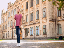
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
			<td>
        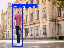
      </td>
      <td align=""center>
        <font size="96px">
        &#11015;
        </font>
      </td>
			<td>
        Дискриминативная нейросеть
      </td>
      <td>
        <img src="" />
      </td>
      <td>
        <img src="" />
      </td>
		</tr>
		<tr>
			<td>
        <img src="" />
      </td>
      <td>
      Генеративная нейросеть
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        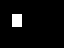
      </td>
			<td>
        <img src="" />
      </td>
      <td>
        <font size="96px">
        &#10145;
        </font>
      </td>
      <td>
        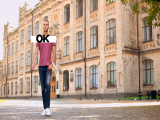
      </td>
		</tr>
</table>

Диаграмма создана


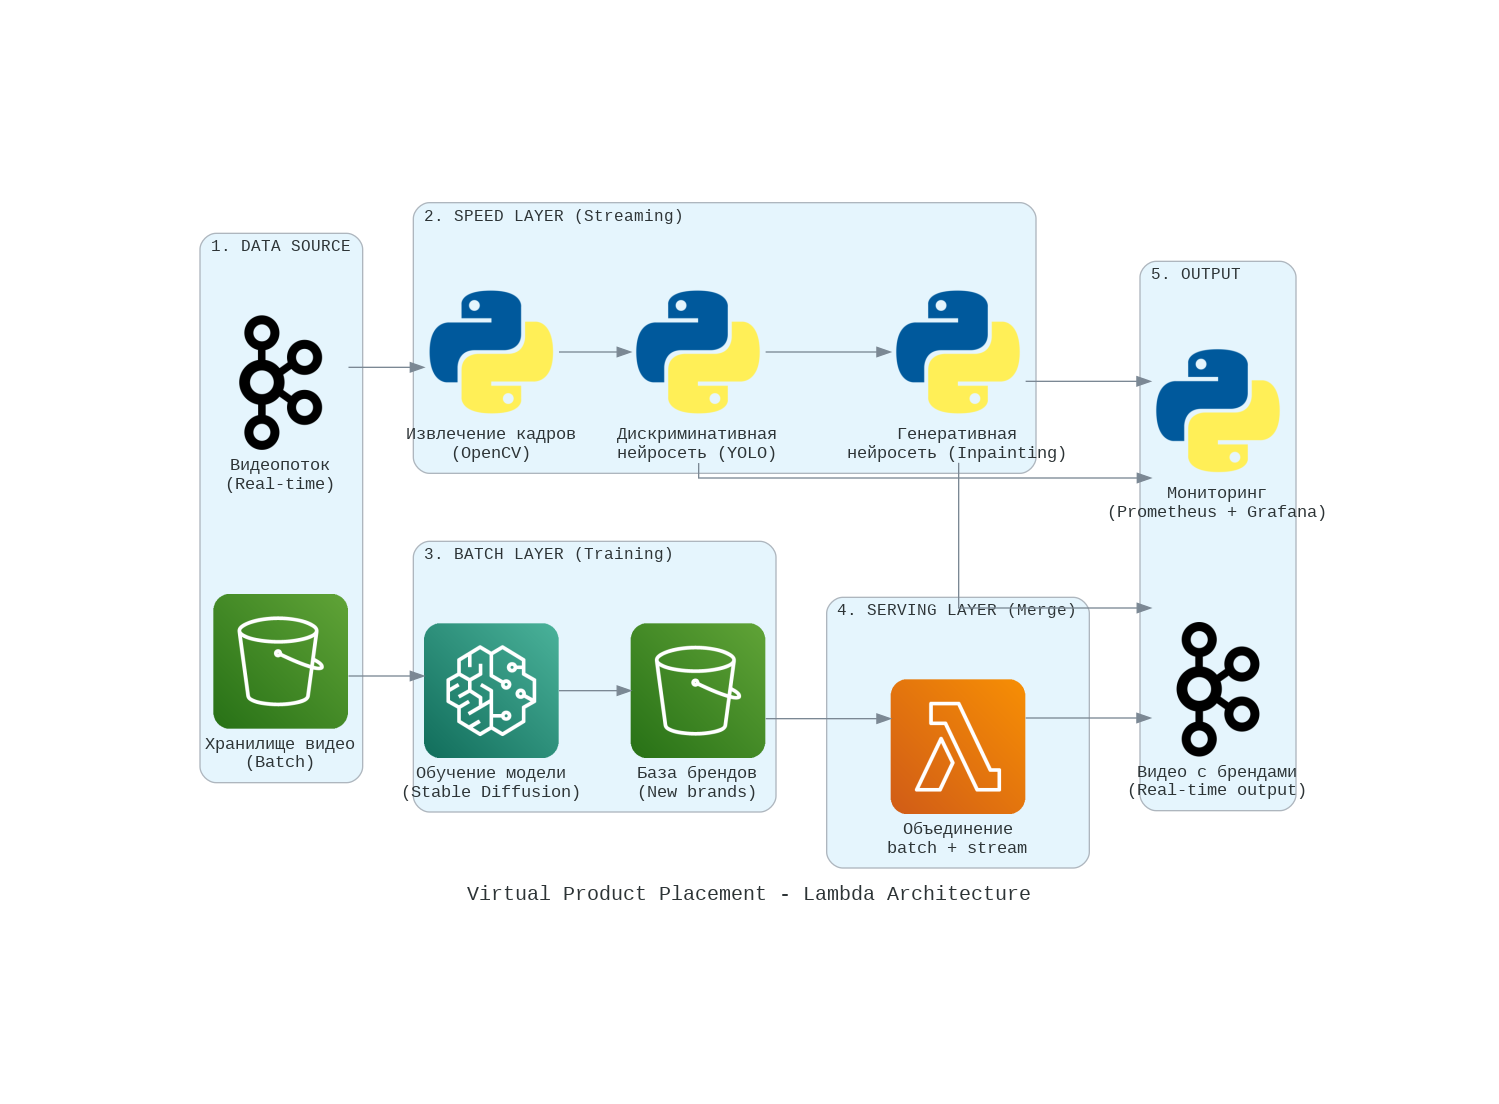

In [16]:
with Diagram("Virtual Product Placement - Lambda Architecture",
             filename="/content/vpp_lambda_architecture",
             show=False,
             direction="LR",
             outformat="png"):

    # Источник данных
    with Cluster("1. DATA SOURCE"):
        video_stream = Kafka("Видеопоток\n(Real-time)")
        video_batch = S3("Хранилище видео\n(Batch)")

    # SPEED LAYER
    with Cluster("2. SPEED LAYER (Streaming)"):
        frame_extractor = Python("Извлечение кадров\n(OpenCV)")
        yolo = Python("Дискриминативная\nнейросеть (YOLO)")
        inpainting = Python("Генеративная\nнейросеть (Inpainting)")

    # BATCH LAYER
    with Cluster("3. BATCH LAYER (Training)"):
        trainer = Sagemaker("Обучение модели\n(Stable Diffusion)")
        brand_db = S3("База брендов\n(New brands)")

    # SERVING LAYER
    with Cluster("4. SERVING LAYER (Merge)"):
        serving = Lambda("Объединение\nbatch + stream")

    # OUTPUT
    with Cluster("5. OUTPUT"):
        output = Kafka("Видео с брендами\n(Real-time output)")
        monitor = Python("Мониторинг\n(Prometheus + Grafana)")

    # Связи
    video_stream >> frame_extractor >> yolo >> inpainting >> output
    video_batch >> trainer >> brand_db >> serving
    serving >> output
    yolo >> monitor
    inpainting >> monitor

print("Диаграмма создана")
Image("/content/vpp_lambda_architecture.png")

## Итоговые выводы

1. **Метрики и SLO** — построили дерево из 4 уровней: бизнес, SLO приложения, ML-метрики, инфраструктура. Это помогает разным командам видеть свою зону ответственности.

2. **Prometheus + Grafana** — настроили сбор метрик latency и error rate, создали дашборд с графиком p95 latency и алерт при превышении 1 секунды.

3. **Дрифт данных** — продемонстрировали с помощью PSI. При умножении признаков на 2 PSI вырос до 24, модель потеряла точность с 100% до 0%.

4. **DQOps** — SQL-код инцидента показывает добавление NULL-значений, дубликатов и аномалий. В production DQOps автоматически детектирует такие проблемы.

5. **Архитектура Virtual Product Placement** — выбрали Lambda архитектуру, так как нужно переобучать генеративную модель на новых брендах.

6. **Главный вывод** — мониторинг ML-системы должен включать не только технические метрики, но и ML-специфичные. Без этого невозможно гарантировать стабильную работу.